In [54]:
import math

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, MCMT, XGate, ZGate
from qiskit.circuit.library import grover_operator
from qiskit.visualization import plot_distribution

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [ ]:
# Task I and II
# Oracle for 001
# oracle = QuantumCircuit(3, name="oracle")
# oracle.x(2)
# oracle.x(1)
# oracle.compose(MCMTGate(ZGate(), 2, 1, ctrl_state=None, label=None), inplace=True)

# oracle.x(2)
# oracle.x(1)

# oracle.draw()

# #Oracle for 010
# oracle = QuantumCircuit(3, name="oracle")
# oracle.x(2)
# oracle.x(0)
# oracle.compose(MCMTGate(ZGate(), 2, 1, ctrl_state=None, label=None), inplace=True)

# oracle.x(2)
# oracle.x(0)

# oracle.draw()


#Oracle for 011
# oracle = QuantumCircuit(3, name="oracle")
# oracle.x(2)

# oracle.compose(MCMTGate(ZGate(), 2, 1, ctrl_state=None, label=None), inplace=True)
# oracle.x(2)


# oracle.draw()


# Oracle for 011 + 101 (Task II)
oracle = QuantumCircuit(3, name="oracle")

oracle.cz(2,0)

oracle.cz(1,0)

oracle.draw()





q_0: ─■──■─
      │  │ 
q_1: ─┼──■─
      │    
q_2: ─■────

In [96]:
#Task I and II
# we see that the amplitude is changing for 001
from qiskit.quantum_info import Statevector

state = Statevector.from_label("011")
state_after = state.evolve(oracle)

display(state.draw('latex'))
display(state_after.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [97]:
#Task I and II
# we see that the amplitude is not changing for 111
from qiskit.quantum_info import Statevector

state = Statevector.from_label("111")
state_after = state.evolve(oracle)

display(state.draw('latex'))
display(state_after.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [98]:
#Diffusion part (amplification)

diffusion = QuantumCircuit(3, name="diffusion")

diffusion.h(range(3))
diffusion.x(range(3))

diffusion.compose(
    MCMTGate(ZGate(), 2, 1),
    inplace=True
)

diffusion.x(range(3))
diffusion.h(range(3))

diffusion.draw()



┌───┐┌───┐ 1-Z ┌───┐┌───┐
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     └───┘└───┘     └───┘└───┘

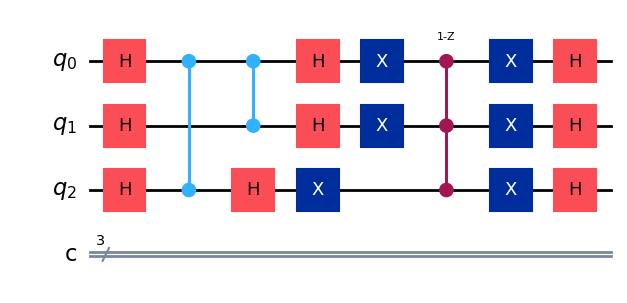

In [99]:
grover = QuantumCircuit(3, 3)

grover.h(range(3))
grover.compose(oracle, inplace=True) # we can put different oracles here for different exerrcises
grover.compose(diffusion, inplace=True)


grover.draw(output="mpl")

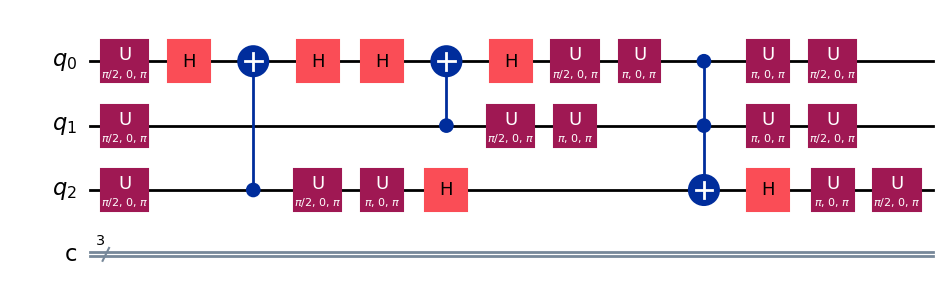

In [100]:
grover.decompose().draw(output="mpl", style="iqp")

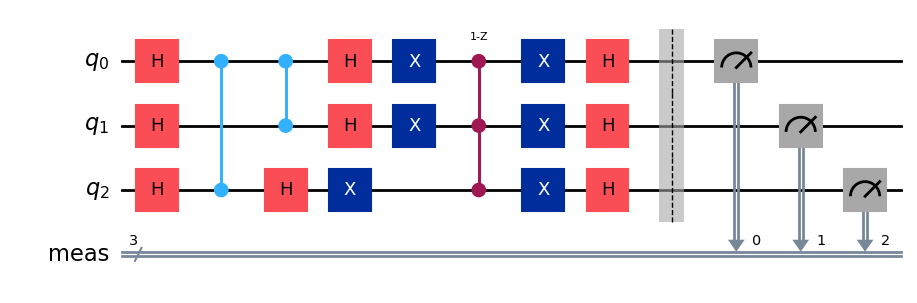

In [103]:
qc = QuantumCircuit(grover.num_qubits)

qc.h(range(grover.num_qubits))

iterations = 1  #optimal

for _ in range(iterations):
    qc.compose(oracle, inplace=True)
    qc.compose(diffusion, inplace=True)

qc.measure_all()

qc.draw(output="mpl", style="iqp")

The probabilities are: {'101': 0.499671, '011': 0.500329}


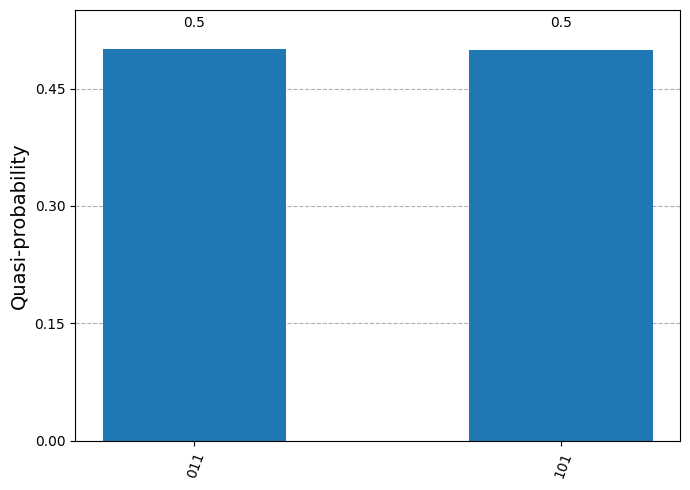

In [104]:
from qiskit.primitives import StatevectorSampler

sampler_simulator = StatevectorSampler()

num_shots = 1000000
result = sampler_simulator.run([qc], shots=num_shots).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()

for i in counts:
    counts[i] = float(counts[i]/num_shots)

print(f"The probabilities are: {counts}")
plot_distribution(counts)

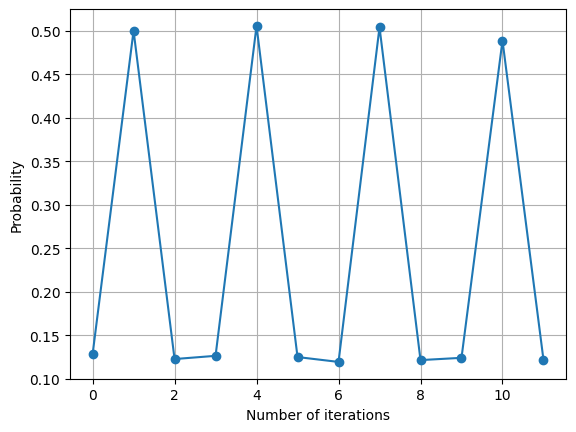

In [109]:
#Task IV
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
import matplotlib.pyplot as plt

n = 3
target = '011'

sampler = StatevectorSampler()
num_shots = 10000

iteration_values = range(0, 12)
target_probs = []

for k in iteration_values:
    qc = QuantumCircuit(n)

    qc.h(range(n))

    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)

    qc.measure_all()

    result = sampler.run([qc], shots=num_shots).result()
    counts = result[0].data.meas.get_counts()

    prob = counts.get(target, 0) / num_shots
    target_probs.append(prob)

plt.figure()
plt.plot(iteration_values, target_probs, marker="o")
plt.xlabel("Number of iterations")
plt.ylabel(f"Probability")
plt.grid()
plt.show()

Now we do the same thing but for larger circuits (4 and 5 qubits)

In [ ]:
#Task V - state 1001
# n=4
# oracle = QuantumCircuit(4, name="oracle")
# oracle.x(2)
# oracle.x(1)
# oracle.compose(MCMTGate(ZGate(), 3, 1, ctrl_state=None, label=None), inplace=True)

# oracle.x(2)
# oracle.x(1)

# oracle.draw()

#Task VI - state 00111
n = 5
oracle = QuantumCircuit(n, name="oracle")
oracle.x(4)
oracle.x(3)
oracle.compose(MCMTGate(ZGate(), n-1, 1, ctrl_state=None, label=None), inplace=True)

oracle.x(4)
oracle.x(3)

oracle.draw()

1-Z      
q_0: ───────■───────
            │       
q_1: ───────■───────
            │       
q_2: ───────■───────
     ┌───┐  │  ┌───┐
q_3: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_4: ┤ X ├──■──┤ X ├
     └───┘     └───┘

In [126]:

from qiskit.quantum_info import Statevector

state = Statevector.from_label("00111")
state_after = state.evolve(oracle)

display(state.draw('latex'))
display(state_after.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [127]:
#Diffusion part (amplification)
diffusion = QuantumCircuit(n, name="diffusion")

diffusion.h(range(n))
diffusion.x(range(n))

diffusion.compose(
    MCMTGate(ZGate(), n-1, 1),
    inplace=True
)

diffusion.x(range(n))
diffusion.h(range(n))

diffusion.draw()


┌───┐┌───┐ 1-Z ┌───┐┌───┐
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_3: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_4: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     └───┘└───┘     └───┘└───┘

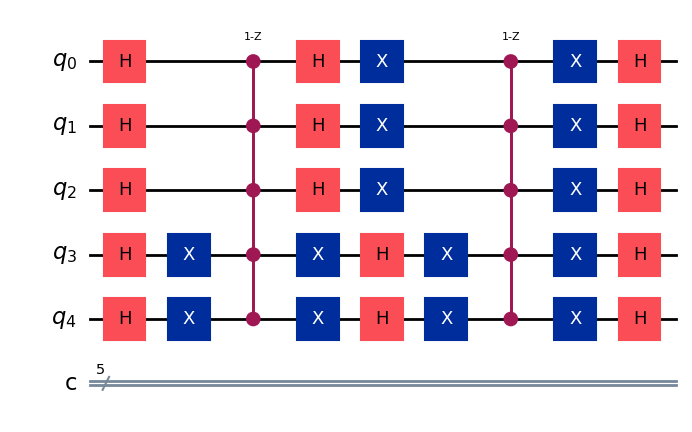

In [128]:
grover = QuantumCircuit(n, n)

grover.h(range(n))
grover.compose(oracle, inplace=True) # we can put different oracles here for different exerrcises
grover.compose(diffusion, inplace=True)


grover.draw(output="mpl")

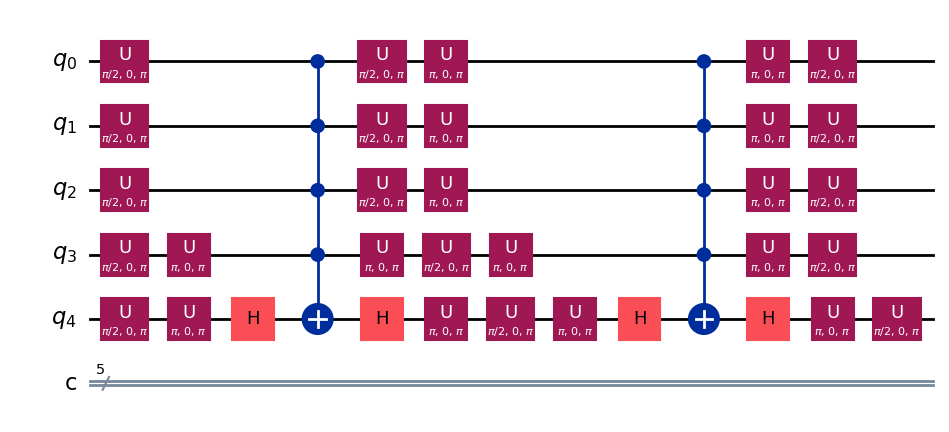

In [129]:
grover.decompose().draw(output="mpl", style="iqp")

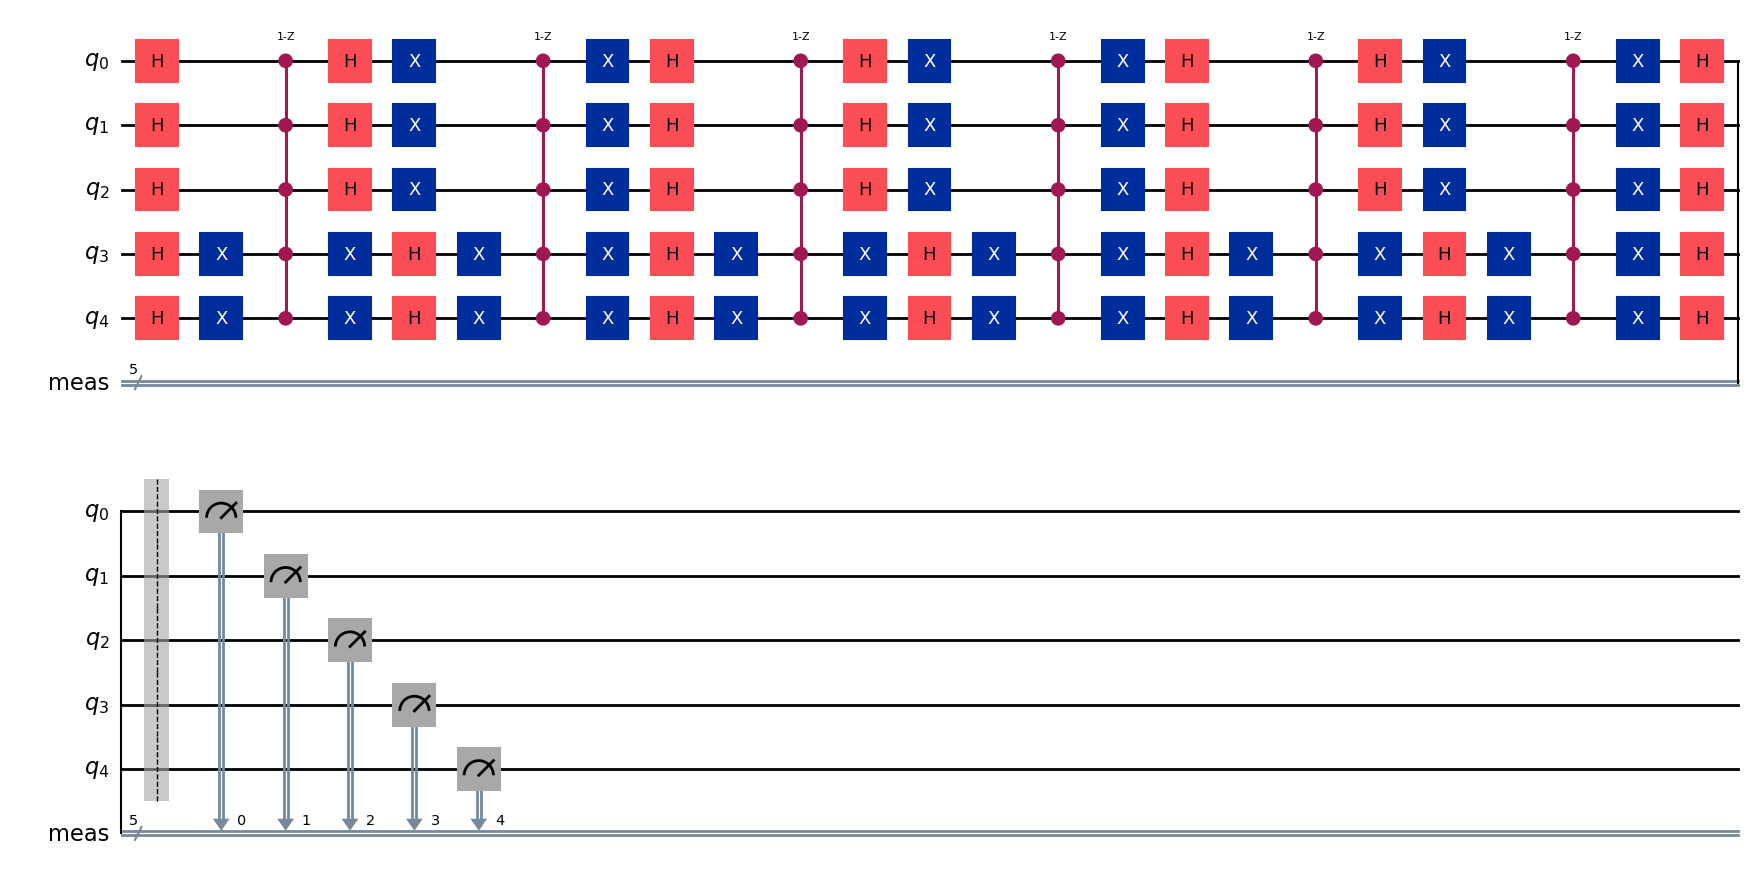

In [130]:
qc = QuantumCircuit(grover.num_qubits)

qc.h(range(grover.num_qubits))

iterations = 3  #optimal

for _ in range(iterations):
    qc.compose(oracle, inplace=True)
    qc.compose(diffusion, inplace=True)

qc.measure_all()

qc.draw(output="mpl", style="iqp")

The probabilities are: {'00111': 0.897312, '10000': 0.00334, '11011': 0.003357, '00011': 0.003374, '01010': 0.003293, '11110': 0.003228, '01001': 0.003358, '10110': 0.003367, '00010': 0.003461, '10100': 0.003256, '00000': 0.003333, '01011': 0.003274, '01110': 0.003302, '11101': 0.003219, '01000': 0.003247, '10101': 0.003323, '01100': 0.003272, '11100': 0.00333, '11000': 0.003335, '10010': 0.003148, '11010': 0.003327, '10001': 0.003416, '01101': 0.003265, '00110': 0.00333, '00101': 0.003389, '01111': 0.003415, '00100': 0.003252, '00001': 0.003281, '11001': 0.003359, '10011': 0.00327, '11111': 0.00327, '10111': 0.003297}


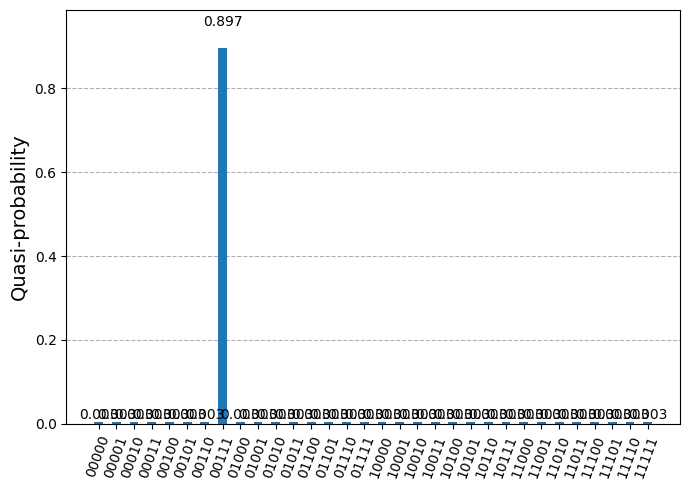

In [131]:
from qiskit.primitives import StatevectorSampler

sampler_simulator = StatevectorSampler()

num_shots = 1000000
result = sampler_simulator.run([qc], shots=num_shots).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()

for i in counts:
    counts[i] = float(counts[i]/num_shots)

print(f"The probabilities are: {counts}")
plot_distribution(counts)

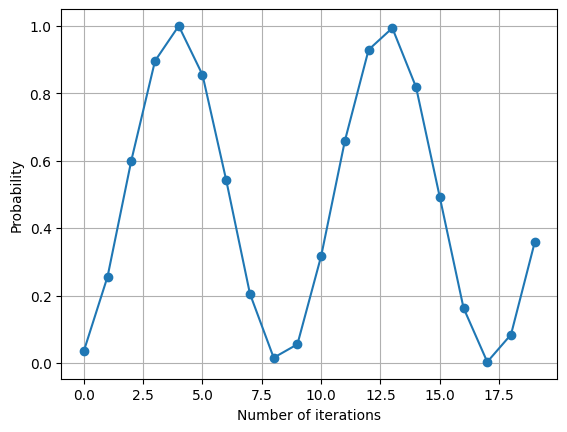

In [133]:
#Task IV
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
import matplotlib.pyplot as plt

target = '00111'

sampler = StatevectorSampler()
num_shots = 10000

iteration_values = range(0, 20)
target_probs = []

for k in iteration_values:
    qc = QuantumCircuit(n)

    qc.h(range(n))

    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)

    qc.measure_all()

    result = sampler.run([qc], shots=num_shots).result()
    counts = result[0].data.meas.get_counts()

    prob = counts.get(target, 0) / num_shots
    target_probs.append(prob)

plt.figure()
plt.plot(iteration_values, target_probs, marker="o")
plt.xlabel("Number of iterations")
plt.ylabel(f"Probability")
plt.grid()
plt.show()